# 🤖 Multiagent Research System — prefix (HITL)
### Built with LangChain + LangGraph | Groq / OpenAI LLMs | Human-in-the-Loop

A **4-agent pipeline** with **2 human review checkpoints** that takes any research topic and produces:
- 📄 A comprehensive written report
- 📊 A data visualization chart

```
START → Researcher → 🧑 Human Review (Notes) → Analyst → Writer → 🧑 Human Review (Report) → Graph Creator → END
```

| Step | Agent / Action | Input | Output |
|---|---|---|---|
| 1 | **Researcher** | topic | raw research notes |
| 2 | **🧑 Human Review** | research notes | approved / edited notes |
| 3 | **Data Analyst** | research notes | JSON chart data |
| 4 | **Report Writer** | notes + chart data | polished report |
| 5 | **🧑 Human Review** | draft report | approved / edited report |
| 6 | **Graph Creator** | chart data | matplotlib PNG |

In [1]:
## ── Cell 1: Install / verify dependencies ──────────────────────────────────
%pip install -q langchain langchain-groq langchain-openai langgraph python-dotenv matplotlib

Note: you may need to restart the kernel to use updated packages.


c:\Users\E264598\OneDrive - WFT\Desktop\Sohail Learning\Euron\Agentic AI System\10th May\smsfinal\.venv\Scripts\python.exe: No module named pip


In [2]:
## ── Cell 2: Imports ────────────────────────────────────────────────────────
import os, json, re, textwrap
from typing import TypedDict, Annotated, Optional
from dotenv import load_dotenv

import matplotlib.pyplot as plt
import numpy as np

from langchain_core.messages import HumanMessage, SystemMessage
from langchain_core.prompts import ChatPromptTemplate

from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt, Command

load_dotenv()

# ── LLM setup: prefer Groq (fast), fall back to OpenAI ─────────────────────
try:
    from langchain_groq import ChatGroq
    llm = ChatGroq(model="llama-3.3-70b-versatile", temperature=0.3)
    llm.invoke("hi")          # quick connectivity test
    print("✅ Using Groq  →  llama-3.3-70b-versatile")
except Exception as e:
    print(f"⚠️  Groq unavailable ({e.__class__.__name__}), switching to OpenAI …")
    from langchain_openai import ChatOpenAI
    llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.3)
    print("✅ Using OpenAI  →  gpt-4o-mini")

✅ Using Groq  →  llama-3.3-70b-versatile


In [3]:
## ── Cell 3: Shared State ───────────────────────────────────────────────────
class ResearchState(TypedDict):
    topic: str                         # user input
    research_notes: str                # raw research from Researcher agent
    human_feedback_notes: str          # human edits/approval of research notes
    structured_data: dict              # JSON data for charting from Analyst agent
    report: str                        # polished text from Writer agent
    human_feedback_report: str         # human edits/approval of report
    chart_path: str                    # saved chart file path

print("✅ State schema defined")

✅ State schema defined


In [4]:
## ── Cell 4: Agent Node Functions ───────────────────────────────────────────

# ── Agent 1: Researcher ─────────────────────────────────────────────────────
def researcher_agent(state: ResearchState) -> ResearchState:
    """Gathers comprehensive information about the topic."""
    print(f"\n🔍 [Researcher]  Researching: '{state['topic']}' …")
    prompt = ChatPromptTemplate.from_messages([
        SystemMessage(content=(
            "You are an expert research analyst. Given a topic, provide detailed research notes "
            "covering: overview, history/timeline, key statistics and numbers, major players or "
            "categories, recent developments, and interesting facts. Be factual and include "
            "specific numerical data wherever possible (percentages, years, counts, values)."
        )),
        HumanMessage(content=f"Research topic: {state['topic']}")
    ])
    response = llm.invoke(prompt.format_messages())
    state["research_notes"] = response.content
    print(f"   → Research complete ({len(response.content)} chars)")
    return state


# ── HITL Node 1: Human Review of Research Notes ──────────────────────────────
def human_review_notes(state: ResearchState) -> ResearchState:
    """Pauses for human review of research notes before analysis."""
    print("\n" + "=" * 65)
    print("🧑  HUMAN REVIEW REQUIRED — Research Notes")
    print("=" * 65)
    print("\n📝 Research Notes (preview — first 600 chars):")
    print("-" * 65)
    print(state["research_notes"][:600] + " …")
    print("-" * 65)

    # Interrupt the graph and wait for human input
    # The human can: type 'ok' to approve, or type edited/additional notes
    human_input = interrupt(
        {
            "message": "Review the research notes above. Type 'ok' to approve and continue, "
                       "or type additional context / corrections to append to the notes.",
            "research_notes_preview": state["research_notes"][:600]
        }
    )

    if human_input.strip().lower() == "ok":
        state["human_feedback_notes"] = "approved"
        print("   ✅ Human approved research notes.")
    else:
        # Append human corrections/additions to research notes
        state["research_notes"] = state["research_notes"] + "\n\n[Human additions]:\n" + human_input
        state["human_feedback_notes"] = human_input
        print(f"   ✅ Human added context ({len(human_input)} chars). Notes updated.")
    return state


# ── Agent 2: Data Analyst ────────────────────────────────────────────────────
def analyst_agent(state: ResearchState) -> ResearchState:
    """Extracts structured numerical data from research notes for charting."""
    print("\n📊 [Analyst]  Extracting chartable data …")
    prompt = ChatPromptTemplate.from_messages([
        SystemMessage(content=(
            "You are a data analyst. Read the research notes and extract the MOST INTERESTING "
            "numerical data suitable for a bar chart or line chart. "
            "Respond ONLY with valid JSON — no markdown, no explanation — in this exact schema:\n"
            "{\n"
            '  "chart_title": "string",\n'
            '  "x_label": "string",\n'
            '  "y_label": "string",\n'
            '  "chart_type": "bar" | "line" | "horizontal_bar",\n'
            '  "labels": ["label1", "label2", ...],\n'
            '  "values": [number1, number2, ...],\n'
            '  "colors": ["#hex1", "#hex2", ...],\n'
            '  "insight": "one-sentence takeaway from the chart"\n'
            "}\n"
            "Make labels concise (≤ 20 chars). Provide at least 4 data points."
        )),
        HumanMessage(content=f"Research notes:\n\n{state['research_notes']}")
    ])
    response = llm.invoke(prompt.format_messages())
    raw = response.content.strip()

    json_match = re.search(r'\{.*\}', raw, re.DOTALL)
    if json_match:
        try:
            state["structured_data"] = json.loads(json_match.group())
            print(f"   → Extracted data: {len(state['structured_data'].get('labels', []))} data points")
        except json.JSONDecodeError:
            state["structured_data"] = {}
            print("   ⚠️  Could not parse JSON; chart will be skipped.")
    else:
        state["structured_data"] = {}
    return state


# ── Agent 3: Report Writer ───────────────────────────────────────────────────
def writer_agent(state: ResearchState) -> ResearchState:
    """Writes a well-structured research report."""
    print("\n✍️  [Writer]  Drafting report …")
    prompt = ChatPromptTemplate.from_messages([
        SystemMessage(content=(
            "You are a professional report writer. Using the research notes provided, write a "
            "polished, well-structured research report with clear sections: Executive Summary, "
            "Background, Key Findings, Data Highlights, Conclusion. "
            "Use markdown formatting with headers. Be informative yet concise (~600 words)."
        )),
        HumanMessage(content=(
            f"Topic: {state['topic']}\n\n"
            f"Research notes:\n{state['research_notes']}\n\n"
            f"Chart insight (mention this): {state['structured_data'].get('insight', 'N/A')}"
        ))
    ])
    response = llm.invoke(prompt.format_messages())
    state["report"] = response.content
    print(f"   → Report ready ({len(response.content)} chars)")
    return state


# ── HITL Node 2: Human Review of Draft Report ────────────────────────────────
def human_review_report(state: ResearchState) -> ResearchState:
    """Pauses for human review of the draft report before chart generation."""
    print("\n" + "=" * 65)
    print("🧑  HUMAN REVIEW REQUIRED — Draft Report")
    print("=" * 65)
    print("\n📄 Draft Report (preview — first 800 chars):")
    print("-" * 65)
    print(state["report"][:800] + " …")
    print("-" * 65)

    # Interrupt the graph and wait for human input
    human_input = interrupt(
        {
            "message": "Review the draft report above. Type 'ok' to approve and generate the chart, "
                       "or type specific edits / instructions to revise the report.",
            "report_preview": state["report"][:800]
        }
    )

    if human_input.strip().lower() == "ok":
        state["human_feedback_report"] = "approved"
        print("   ✅ Human approved report.")
    else:
        # Revise the report based on human feedback
        print("   🔄 Revising report based on human feedback …")
        revision_prompt = ChatPromptTemplate.from_messages([
            SystemMessage(content="You are a professional report editor. Revise the report based on the feedback provided."),
            HumanMessage(content=(
                f"Original report:\n{state['report']}\n\n"
                f"Human feedback / edits:\n{human_input}\n\n"
                "Please produce a revised version of the report incorporating the feedback."
            ))
        ])
        revised = llm.invoke(revision_prompt.format_messages())
        state["report"] = revised.content
        state["human_feedback_report"] = human_input
        print(f"   ✅ Report revised ({len(revised.content)} chars).")
    return state


# ── Agent 4: Graph Creator ───────────────────────────────────────────────────
def graph_creator_agent(state: ResearchState) -> ResearchState:
    """Generates a matplotlib chart from structured data."""
    print("\n🎨 [Graph Creator]  Building visualisation …")
    data = state.get("structured_data", {})

    if not data or not data.get("labels") or not data.get("values"):
        print("   ⚠️  No chart data — skipping.")
        state["chart_path"] = ""
        return state

    labels  = data["labels"]
    values  = data["values"]
    colors  = data.get("colors") or plt.cm.tab10.colors[:len(labels)]
    title   = data.get("chart_title", f"Research: {state['topic']}")
    x_label = data.get("x_label", "")
    y_label = data.get("y_label", "")
    ctype   = data.get("chart_type", "bar")

    fig, ax = plt.subplots(figsize=(12, 6))
    fig.patch.set_facecolor("#0f0f1a")
    ax.set_facecolor("#1a1a2e")

    colors = (list(colors) * len(labels))[:len(labels)]

    if ctype == "horizontal_bar":
        bars = ax.barh(labels, values, color=colors, edgecolor="#ffffff22", height=0.6)
        ax.set_xlabel(y_label, color="white", fontsize=11)
        ax.set_ylabel(x_label, color="white", fontsize=11)
        for bar, val in zip(bars, values):
            ax.text(bar.get_width() + max(values)*0.01, bar.get_y() + bar.get_height()/2,
                    f"{val:,.1f}", va="center", color="white", fontsize=9)
    elif ctype == "line":
        ax.plot(labels, values, marker="o", color=colors[0] if colors else "#00d4ff",
                linewidth=2.5, markersize=8, markerfacecolor="white")
        ax.fill_between(range(len(labels)), values, alpha=0.15,
                        color=colors[0] if colors else "#00d4ff")
        ax.set_xlabel(x_label, color="white", fontsize=11)
        ax.set_ylabel(y_label, color="white", fontsize=11)
        ax.set_xticks(range(len(labels)))
        ax.set_xticklabels(labels, rotation=30, ha="right")
        for i, (x, y) in enumerate(zip(range(len(labels)), values)):
            ax.annotate(f"{y:,.1f}", (x, y), textcoords="offset points",
                        xytext=(0, 10), ha="center", color="white", fontsize=9)
    else:  # default: vertical bar
        bars = ax.bar(labels, values, color=colors, edgecolor="#ffffff22", width=0.6)
        ax.set_xlabel(x_label, color="white", fontsize=11)
        ax.set_ylabel(y_label, color="white", fontsize=11)
        ax.set_xticks(range(len(labels)))
        ax.set_xticklabels(labels, rotation=30, ha="right", fontsize=9)
        for bar, val in zip(bars, values):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(values)*0.01,
                    f"{val:,.1f}", ha="center", va="bottom", color="white", fontsize=9)

    ax.set_title(title, color="white", fontsize=14, fontweight="bold", pad=15)
    ax.tick_params(colors="white")
    for spine in ax.spines.values():
        spine.set_edgecolor("#ffffff33")
    ax.grid(axis="y" if ctype != "horizontal_bar" else "x",
            linestyle="--", alpha=0.2, color="white")

    insight = data.get("insight", "")
    if insight:
        fig.text(0.5, 0.01, f"💡 {insight}", ha="center", color="#aaaacc",
                 fontsize=9, style="italic")

    plt.tight_layout(rect=[0, 0.04, 1, 1])

    chart_path = os.path.join(
        os.path.dirname(os.path.abspath(".")),
        "Experiments",
        f"{state['topic'][:30].replace(' ','_')}_prefix_chart.png"
    )
    plt.savefig(chart_path, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.show()
    state["chart_path"] = chart_path
    print(f"   → Chart saved: {chart_path}")
    return state


print("✅ All agent nodes + HITL review nodes defined")

✅ All agent nodes + HITL review nodes defined


In [5]:
## ── Cell 5: Build LangGraph with Checkpointing ─────────────────────────────

# MemorySaver enables graph state persistence across interrupts
memory = MemorySaver()

builder = StateGraph(ResearchState)

# Register nodes
builder.add_node("researcher",           researcher_agent)
builder.add_node("human_review_notes",   human_review_notes)    # HITL checkpoint 1
builder.add_node("analyst",              analyst_agent)
builder.add_node("writer",               writer_agent)
builder.add_node("human_review_report",  human_review_report)   # HITL checkpoint 2
builder.add_node("graph_creator",        graph_creator_agent)

# Define pipeline edges
builder.add_edge(START,                 "researcher")
builder.add_edge("researcher",          "human_review_notes")
builder.add_edge("human_review_notes",  "analyst")
builder.add_edge("analyst",             "writer")
builder.add_edge("writer",              "human_review_report")
builder.add_edge("human_review_report", "graph_creator")
builder.add_edge("graph_creator",        END)

# Compile with MemorySaver as checkpointer (required for interrupt to work)
research_graph = builder.compile(checkpointer=memory)

print("✅ LangGraph (HITL) compiled successfully")
print("\nPipeline flow:")
print("  START → Researcher → 🧑 Human Review (Notes) → Analyst")
print("        → Writer → 🧑 Human Review (Report) → Graph Creator → END")

✅ LangGraph (HITL) compiled successfully

Pipeline flow:
  START → Researcher → 🧑 Human Review (Notes) → Analyst
        → Writer → 🧑 Human Review (Report) → Graph Creator → END


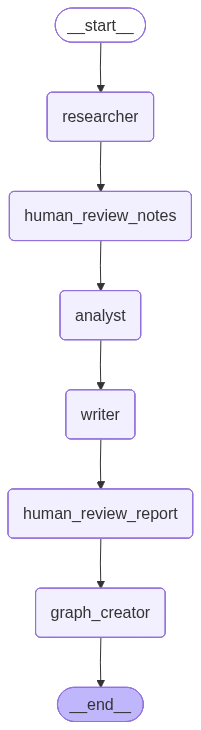

In [6]:
## ── Cell 6: Visualise the Graph Architecture ───────────────────────────────
from IPython.display import Image, display

try:
    img = research_graph.get_graph().draw_mermaid_png()
    display(Image(img))
except Exception:
    print(research_graph.get_graph().draw_ascii())

In [7]:
## ── Cell 7: STEP 1 — Start the pipeline (runs until first HITL interrupt) ──

# ┌──────────────────────────────────────────────────────────────┐
# │  👇  Change this topic to research anything you want         │
RESEARCH_TOPIC = "population in india"
# └──────────────────────────────────────────────────────────────┘

# Each run uses a unique thread_id so checkpoints are isolated
THREAD_ID = "hitl-run-1"
config = {"configurable": {"thread_id": THREAD_ID}}

initial_state: ResearchState = {
    "topic":                  RESEARCH_TOPIC,
    "research_notes":         "",
    "human_feedback_notes":   "",
    "structured_data":        {},
    "report":                 "",
    "human_feedback_report":  "",
    "chart_path":             "",
}

print("=" * 65)
print(f"  MULTIAGENT RESEARCH SYSTEM — prefix (HITL)")
print(f"  Topic: {RESEARCH_TOPIC}")
print("=" * 65)

# Run until the first interrupt (after Researcher)
result = research_graph.invoke(initial_state, config=config)

# Check if graph is paused at an interrupt
if "__interrupt__" in result:
    interrupt_info = result["__interrupt__"][0]
    print("\n" + "🛑 " * 20)
    print("  GRAPH PAUSED — waiting for human input")
    print("  Message:", interrupt_info.value["message"])
    print("🛑 " * 20)
    print("\n👉 Run Cell 8 to provide your feedback on the research notes.")
else:
    print("\n✅ Pipeline ran to completion (no interrupt encountered).")

  MULTIAGENT RESEARCH SYSTEM — prefix (HITL)
  Topic: population in india

🔍 [Researcher]  Researching: 'population in india' …
   → Research complete (4087 chars)

🧑  HUMAN REVIEW REQUIRED — Research Notes

📝 Research Notes (preview — first 600 chars):
-----------------------------------------------------------------
**Overview**
India is the second-most populous country in the world, with a large and diverse population. The country's population has been growing rapidly, driven by a combination of factors including a high birth rate, improved healthcare, and increased life expectancy. The population of India is projected to continue growing, with significant implications for the country's economy, environment, and social services.

**History/Timeline**

* 1901: The population of India was approximately 238 million.
* 1951: The population of India was approximately 361 million, with an average annual growth …
-----------------------------------------------------------------

🛑 🛑 🛑 🛑 🛑 

In [8]:
## ── Cell 8: STEP 2 — Human Feedback on Research Notes ─────────────────────
# Provide your feedback below:
#   • Type 'ok'  → approve notes as-is and continue
#   • Type text  → additional context / corrections will be appended to notes

FEEDBACK_NOTES = "ok"    # ← change this

print(f"Submitting feedback: '{FEEDBACK_NOTES}'")

result2 = research_graph.invoke(Command(resume=FEEDBACK_NOTES), config=config)

if "__interrupt__" in result2:
    interrupt_info = result2["__interrupt__"][0]
    print("\n" + "🛑 " * 20)
    print("  GRAPH PAUSED AGAIN — waiting for report review")
    print("  Message:", interrupt_info.value["message"])
    print("🛑 " * 20)
    print("\n👉 Run Cell 9 to review and approve (or edit) the draft report.")
else:
    print("\n✅ Pipeline completed after notes feedback.")

Submitting feedback: 'ok'

🧑  HUMAN REVIEW REQUIRED — Research Notes

📝 Research Notes (preview — first 600 chars):
-----------------------------------------------------------------
**Overview**
India is the second-most populous country in the world, with a large and diverse population. The country's population has been growing rapidly, driven by a combination of factors including a high birth rate, improved healthcare, and increased life expectancy. The population of India is projected to continue growing, with significant implications for the country's economy, environment, and social services.

**History/Timeline**

* 1901: The population of India was approximately 238 million.
* 1951: The population of India was approximately 361 million, with an average annual growth …
-----------------------------------------------------------------
   ✅ Human approved research notes.

📊 [Analyst]  Extracting chartable data …
   → Extracted data: 8 data points

✍️  [Writer]  Drafting report …
   

Submitting report feedback: 'ok'

🧑  HUMAN REVIEW REQUIRED — Draft Report

📄 Draft Report (preview — first 800 chars):
-----------------------------------------------------------------
### Executive Summary
India is the second-most populous country in the world, with a large and diverse population that has been growing rapidly. The country's population is projected to continue growing, with significant implications for the economy, environment, and social services. This report provides an overview of the population in India, including key statistics, trends, and projections. According to the chart insight, India's population is projected to continue growing, reaching 1.64 billion by 2050.

### Background
The population of India has been growing rapidly, driven by a combination of factors including a high birth rate, improved healthcare, and increased life expectancy. The country's population has grown from approximately 238 million in 1901 to 1.38 billion in 2020, with a …
------------

C:\Users\E264598\AppData\Local\Temp\ipykernel_21208\908891789.py:230: UserWarning: Glyph 128161 (\N{ELECTRIC LIGHT BULB}) missing from font(s) DejaVu Sans.
  plt.savefig(chart_path, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
c:\Users\E264598\OneDrive - WFT\Desktop\Sohail Learning\Euron\Agentic AI System\10th May\smsfinal\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128161 (\N{ELECTRIC LIGHT BULB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


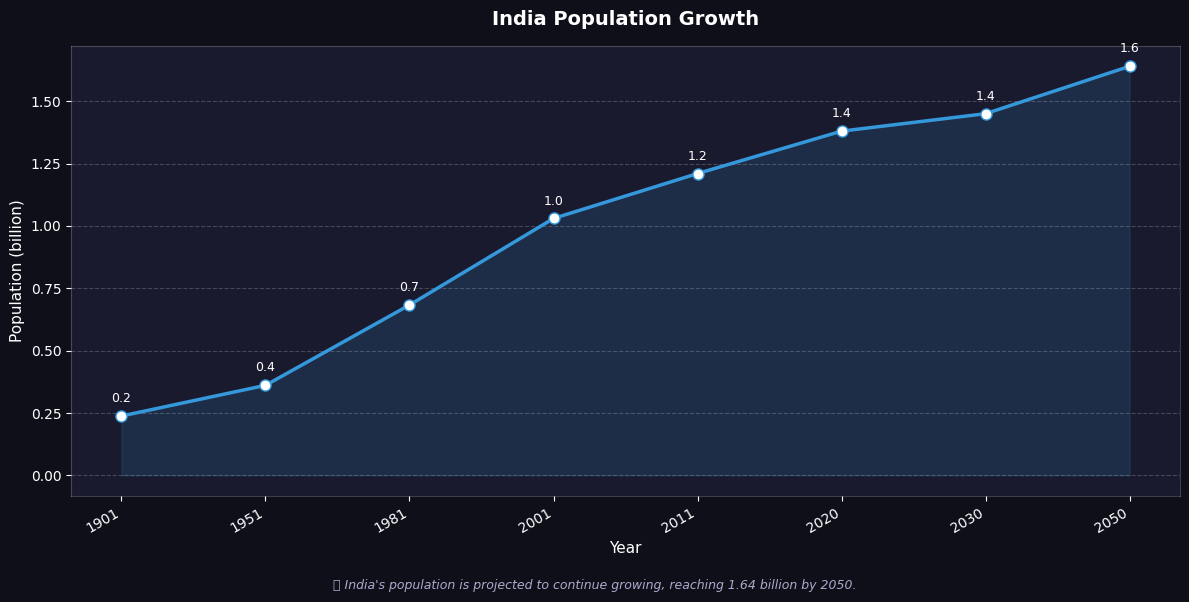

   → Chart saved: c:\Users\E264598\OneDrive - WFT\Desktop\Sohail Learning\Euron\Agentic AI System\10th May\smsfinal\Experiments\population_in_india_prefix_chart.png

  ✅  All agents + human reviews completed!


In [9]:
## ── Cell 9: STEP 3 — Human Feedback on Draft Report ───────────────────────
# Provide your feedback below:
#   • Type 'ok'  → approve the report and trigger chart generation
#   • Type text  → the report will be revised by the LLM using your instructions

FEEDBACK_REPORT = "ok"   # ← change this

print(f"Submitting report feedback: '{FEEDBACK_REPORT}'")

final_state = research_graph.invoke(Command(resume=FEEDBACK_REPORT), config=config)

print("\n" + "=" * 65)
print("  ✅  All agents + human reviews completed!")
print("=" * 65)

In [10]:
## ── Cell 10: Display the Final Report ─────────────────────────────────────
from IPython.display import Markdown, display

print("\n" + "━" * 65)
print("  📄  FINAL RESEARCH REPORT")
print("━" * 65 + "\n")
display(Markdown(final_state["report"]))


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  📄  FINAL RESEARCH REPORT
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━



### Executive Summary
India is the second-most populous country in the world, with a large and diverse population that has been growing rapidly. The country's population is projected to continue growing, with significant implications for the economy, environment, and social services. This report provides an overview of the population in India, including key statistics, trends, and projections. According to the chart insight, India's population is projected to continue growing, reaching 1.64 billion by 2050.

### Background
The population of India has been growing rapidly, driven by a combination of factors including a high birth rate, improved healthcare, and increased life expectancy. The country's population has grown from approximately 238 million in 1901 to 1.38 billion in 2020, with an average annual growth rate of 1.2%. The population is projected to reach 1.45 billion by 2030 and 1.64 billion by 2050.

### Key Findings
The key findings of this report include:
* The total population of India was 1.38 billion in 2020, with a population growth rate of 1.2% per annum.
* The birth rate in India was 18.3 births per 1,000 people in 2020, while the death rate was 7.3 deaths per 1,000 people.
* The life expectancy at birth in India was 69.5 years in 2020, with an urban population of 34.5% and a rural population of 65.5%.
* The sex ratio in India was 943 females per 1,000 males in 2020, with a literacy rate of 77.7% of the population aged 7 and above.

### Data Highlights
The data highlights of this report include:
* The top 10 most populous cities in India, with Delhi being the most populous city with a population of 29.2 million.
* The top 5 states with the highest rural population, with Uttar Pradesh having the highest rural population of 155 million.
* The age structure of the population, with 29.5% of the population under the age of 14 and 41.5% of the population between the ages of 25 and 54.
* The use of contraceptives has increased, with 54% of married women using some form of contraception in 2019-21.
* The total fertility rate (TFR) in India has declined from 3.4 children per woman in 1992-93 to 2.3 children per woman in 2019-21.

### Conclusion
In conclusion, the population of India is projected to continue growing, with significant implications for the economy, environment, and social services. The government has implemented various population control measures, including the National Population Policy and the Mission Parivar Vikas, which have contributed to a decline in the total fertility rate and an increase in the use of contraceptives. However, more needs to be done to address the challenges posed by the growing population, including improving healthcare and education, and promoting sustainable development. As the chart insight shows, India's population is projected to reach 1.64 billion by 2050, emphasizing the need for continued efforts to manage population growth and ensure a sustainable future for the country.

In [11]:
## ── Cell 11: Display Chart Metadata, HITL Feedback Log & Raw Notes ─────────

# Chart data summary
data = final_state.get("structured_data", {})
if data:
    print("\n📊  Chart Data Extracted by Analyst Agent:")
    print(f"   Title      : {data.get('chart_title', 'N/A')}")
    print(f"   Chart type : {data.get('chart_type', 'N/A')}")
    print(f"   X-axis     : {data.get('x_label', 'N/A')}")
    print(f"   Y-axis     : {data.get('y_label', 'N/A')}")
    print(f"   Data points: {len(data.get('labels', []))}")
    print(f"   Insight    : {data.get('insight', 'N/A')}")
    if final_state.get("chart_path"):
        print(f"   Saved to   : {final_state['chart_path']}")
else:
    print("⚠️  No structured chart data was extracted.")

# HITL feedback log
print("\n" + "─" * 65)
print("🧑  Human-in-the-Loop Feedback Log:")
print("─" * 65)
fb_notes  = final_state.get("human_feedback_notes", "N/A")
fb_report = final_state.get("human_feedback_report", "N/A")
print(f"   Notes feedback  : {fb_notes[:120] if fb_notes else 'N/A'}")
print(f"   Report feedback : {fb_report[:120] if fb_report else 'N/A'}")

# Raw research notes preview
print("\n" + "─" * 65)
print("📝  Raw Research Notes (first 800 chars):")
print("─" * 65)
print(final_state["research_notes"][:800] + " …")


📊  Chart Data Extracted by Analyst Agent:
   Title      : India Population Growth
   Chart type : line
   X-axis     : Year
   Y-axis     : Population (billion)
   Data points: 8
   Insight    : India's population is projected to continue growing, reaching 1.64 billion by 2050.
   Saved to   : c:\Users\E264598\OneDrive - WFT\Desktop\Sohail Learning\Euron\Agentic AI System\10th May\smsfinal\Experiments\population_in_india_prefix_chart.png

─────────────────────────────────────────────────────────────────
🧑  Human-in-the-Loop Feedback Log:
─────────────────────────────────────────────────────────────────
   Notes feedback  : approved
   Report feedback : approved

─────────────────────────────────────────────────────────────────
📝  Raw Research Notes (first 800 chars):
─────────────────────────────────────────────────────────────────
**Overview**
India is the second-most populous country in the world, with a large and diverse population. The country's population has been growing rapidly

---
## 🔁 Run on a Different Topic

Change `RESEARCH_TOPIC` in **Cell 7** and set a new `THREAD_ID` (e.g. `"hitl-run-2"`) to avoid reusing cached state.

```python
RESEARCH_TOPIC = "Artificial Intelligence in Healthcare"
THREAD_ID = "hitl-run-2"
```

Then **re-run cells 7 → 8 → 9** to get a fresh report with HITL review.

---
### Architecture Recap (HITL version)

```
┌──────────┐  ┌───────────────┐  ┌─────────┐  ┌────────┐  ┌───────────────┐  ┌──────────────┐
│Researcher│─▶│🧑 Review Notes│─▶│ Analyst │─▶│ Writer │─▶│🧑 Review Report│─▶│ Graph Creator│
└──────────┘  └───────────────┘  └─────────┘  └────────┘  └───────────────┘  └──────────────┘
  raw facts     approve / edit    JSON chart    markdown     approve / revise     matplotlib
  & stats         or append         data         report        with LLM            chart
```

### How HITL Works

- `interrupt()` inside a node **pauses** graph execution and stores state in `MemorySaver`
- `Command(resume=...)` **resumes** from the exact checkpoint with your input
- Each `thread_id` in `config` is an isolated conversation/run